In [3]:
# 📘 1. IMPORT LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter display settings
%matplotlib inline

# Optional: improve plot style
sns.set(style="whitegrid")


In [4]:

import pandas as pd

# Correct local path
file_path = "../data/guru.xlsx"

# Load sheets
deliveries_df = pd.read_excel(file_path, sheet_name="ball_by_ball_data")
matches_df = pd.read_excel(file_path, sheet_name="ipl_matches_data")

# Check shapes
print("Deliveries shape:", deliveries_df.shape)
print("Matches shape:", matches_df.shape)


# Create working copies (best practice)
deliveries = deliveries_df.copy()
matches = matches_df.copy()


Deliveries shape: (260920, 17)
Matches shape: (1095, 20)


In [5]:
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   object        
 2   city             1044 non-null   str           
 3   date             1095 non-null   datetime64[us]
 4   match_type       1095 non-null   str           
 5   player_of_match  1090 non-null   str           
 6   venue            1095 non-null   str           
 7   team1            1095 non-null   str           
 8   team2            1095 non-null   str           
 9   toss_winner      1095 non-null   str           
 10  toss_decision    1095 non-null   str           
 11  winner           1090 non-null   str           
 12  result           1095 non-null   str           
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64       
 15

In [7]:
matches_df[['id', 'result_margin', 'target_runs', 'target_overs']].describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


**Data Cleaning**

In [8]:
# Drop rows with missing values in the 'winner' column
matches = matches.dropna(subset=['winner'])

In [9]:
# Impute missing values in 'player_of_match'
matches['player_of_match'] = matches['player_of_match'].fillna('Unknown')

In [10]:
# Drop unwanted columns from the dataset (ignore errors if column not found)
matches.drop(['id', 'city', 'method'], axis=1, inplace=True, errors='ignore')

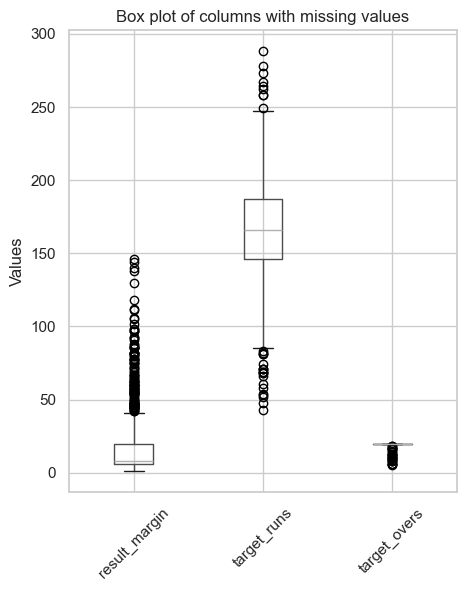

In [11]:
import matplotlib.pyplot as plt

columns_to_handle_missing = ['result_margin', 'target_runs', 'target_overs']

# Plot box plots for each column (select only existing numeric columns)
existing_columns = [col for col in columns_to_handle_missing if col in matches.columns]

plt.figure(figsize=(5, 6))
matches[existing_columns].boxplot()
plt.title('Box plot of columns with missing values')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Impute selected columns with median because they have outliers

for col in ['result_margin', 'target_runs', 'target_overs']:
    if col in matches.columns:
        matches[col] = matches[col].fillna(matches[col].median())

In [13]:
matches.info()

<class 'pandas.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season           1090 non-null   object        
 1   date             1090 non-null   datetime64[us]
 2   match_type       1090 non-null   str           
 3   player_of_match  1090 non-null   str           
 4   venue            1090 non-null   str           
 5   team1            1090 non-null   str           
 6   team2            1090 non-null   str           
 7   toss_winner      1090 non-null   str           
 8   toss_decision    1090 non-null   str           
 9   winner           1090 non-null   str           
 10  result           1090 non-null   str           
 11  result_margin    1090 non-null   float64       
 12  target_runs      1090 non-null   float64       
 13  target_overs     1090 non-null   float64       
 14  super_over       1090 non-null   str           
 15  ump

In [14]:
matches.nunique()

season              17
date               821
match_type           8
player_of_match    291
venue               58
team1               19
team2               19
toss_winner         19
toss_decision        2
winner              19
result               3
result_margin       98
target_runs        169
target_overs        15
super_over           2
umpire1             62
umpire2             62
dtype: int64

**Feature Engineering**

In [15]:
# Convert date column safely
if 'date' in matches.columns:
    matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

    # Extract date features
    matches['year'] = matches['date'].dt.year
    matches['month'] = matches['date'].dt.month
    matches['day'] = matches['date'].dt.day

    # Drop the original date column
    matches.drop('date', axis=1, inplace=True)

In [16]:
# Function to split season values safely
def split_season(season):
    if pd.isna(season):
        return None, None

    season = str(season)

    if '/' in season:
        start, end = season.split('/')
        start = int(start)
        end = int('20' + end) if len(end) == 2 else int(end)
    else:
        start = end = int(season)

    return start, end


# Apply the function safely
matches[['season_start', 'season_end']] = (
    matches['season']
    .dropna()
    .apply(lambda x: pd.Series(split_season(x)))
)

# Convert to numeric year safely
matches['season_start'] = pd.to_datetime(
    matches['season_start'], format='%Y', errors='coerce'
).dt.year

matches['season_end'] = pd.to_datetime(
    matches['season_end'], format='%Y', errors='coerce'
).dt.year




In [17]:
# View unique winners
matches['winner'].unique()

<StringArray>
[      'Kolkata Knight Riders',         'Chennai Super Kings',
            'Delhi Daredevils', 'Royal Challengers Bangalore',
            'Rajasthan Royals',             'Kings XI Punjab',
             'Deccan Chargers',              'Mumbai Indians',
               'Pune Warriors',        'Kochi Tuskers Kerala',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
              'Gujarat Titans',        'Lucknow Super Giants',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [18]:
# Mapping dictionary for old names to standardized names
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Pune Warriors',
    'Rising Pune Supergiant': 'Pune Warriors',
    'Gujarat Lions': 'Gujarat Titans',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
}

team_columns = ['winner', 'team1', 'team2', 'toss_winner']

# Apply replacement safely only for existing columns
existing_team_columns = [col for col in team_columns if col in matches.columns]

matches[existing_team_columns] = matches[existing_team_columns].replace(team_name_mapping)


In [19]:
matches.info()

<class 'pandas.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           1090 non-null   object 
 1   match_type       1090 non-null   str    
 2   player_of_match  1090 non-null   str    
 3   venue            1090 non-null   str    
 4   team1            1090 non-null   str    
 5   team2            1090 non-null   str    
 6   toss_winner      1090 non-null   str    
 7   toss_decision    1090 non-null   str    
 8   winner           1090 non-null   str    
 9   result           1090 non-null   str    
 10  result_margin    1090 non-null   float64
 11  target_runs      1090 non-null   float64
 12  target_overs     1090 non-null   float64
 13  super_over       1090 non-null   str    
 14  umpire1          1090 non-null   str    
 15  umpire2          1090 non-null   str    
 16  year             1090 non-null   int32  
 17  month            1090 non-null

**Feature Extraction from the matches dataset**

In [20]:
# Create team list safely
teams = pd.concat([
    matches['team1'] if 'team1' in matches.columns else pd.Series(),
    matches['team2'] if 'team2' in matches.columns else pd.Series()
]).dropna().unique()

team_stats = pd.DataFrame(teams, columns=['team_name'])

team_stats

,team_name
0,Royal Challengers Bangalore
1,Punjab Kings
2,Delhi Capitals
3,Mumbai Indians
4,Kolkata Knight Riders
5,Rajasthan Royals
6,Sunrisers Hyderabad
7,Chennai Super Kings
8,Kochi Tuskers Kerala
9,Pune Warriors


In [21]:
# Calculate matches played and won safely
team_stats['matches_played'] = team_stats['team_name'].apply(
    lambda x: len(matches[
        ((matches['team1'] == x) if 'team1' in matches.columns else False) |
        ((matches['team2'] == x) if 'team2' in matches.columns else False)
    ])
)

team_stats['matches_won'] = team_stats['team_name'].apply(
    lambda x: len(matches[matches['winner'] == x]) if 'winner' in matches.columns else 0
)

# Avoid division by zero
team_stats['win_percentage'] = (
    team_stats['matches_won'] / team_stats['matches_played'].replace(0, pd.NA)
) * 100

team_stats

,team_name,matches_played,matches_won,win_percentage
0,Royal Challengers Bangalore,252,123,48.809524
1,Punjab Kings,246,112,45.528455
2,Delhi Capitals,250,115,46.000000
3,Mumbai Indians,261,144,55.172414
4,Kolkata Knight Riders,251,131,52.191235
5,Rajasthan Royals,219,112,51.141553
6,Sunrisers Hyderabad,257,117,45.525292
7,Chennai Super Kings,237,138,58.227848
8,Kochi Tuskers Kerala,14,6,42.857143
9,Pune Warriors,75,27,36.000000


In [22]:
# Calculate runs and wickets safely
team_stats['total_runs_scored'] = team_stats['team_name'].apply(
    lambda x: (
        matches[matches['team1'] == x]['target_runs'].sum() if 'target_runs' in matches.columns else 0
    ) + (
        matches[matches['team2'] == x]['target_runs'].sum() if 'target_runs' in matches.columns else 0
    )
)

team_stats['total_wickets_taken'] = team_stats['team_name'].apply(
    lambda x: (
        matches[matches['team1'] == x]['target_overs'].sum() if 'target_overs' in matches.columns else 0
    ) + (
        matches[matches['team2'] == x]['target_overs'].sum() if 'target_overs' in matches.columns else 0
    )
)

# Safe type conversion
team_stats['total_runs_scored'] = team_stats['total_runs_scored'].fillna(0).astype(int)
team_stats['total_wickets_taken'] = team_stats['total_wickets_taken'].fillna(0).astype(int)

team_stats

,team_name,matches_played,matches_won,win_percentage,total_runs_scored,total_wickets_taken
0,Royal Challengers Bangalore,252,123,48.809524,42542,4975
1,Punjab Kings,246,112,45.528455,41178,4854
2,Delhi Capitals,250,115,46.000000,41234,4920
3,Mumbai Indians,261,144,55.172414,43728,5214
4,Kolkata Knight Riders,251,131,52.191235,40557,4907
5,Rajasthan Royals,219,112,51.141553,36187,4358
6,Sunrisers Hyderabad,257,117,45.525292,42118,5080
7,Chennai Super Kings,237,138,58.227848,39503,4693
8,Kochi Tuskers Kerala,14,6,42.857143,2014,277
9,Pune Warriors,75,27,36.000000,11514,1471


In [23]:
# Average runs per match (avoid division by zero)
team_stats['average_runs_scored_per_match'] = (
    team_stats['total_runs_scored'] /
    team_stats['matches_played'].replace(0, pd.NA)
)

# Run rate (safe column checks & division)
team_stats['run_rate'] = team_stats['team_name'].apply(
    lambda x: (
        deliveries[deliveries['batting_team'] == x]['total_runs'].sum() /
        ((deliveries[deliveries['batting_team'] == x].shape[0] / 6)
         if deliveries[deliveries['batting_team'] == x].shape[0] != 0 else pd.NA)
    ) if {'batting_team', 'total_runs'}.issubset(deliveries.columns) else pd.NA
)

# Economy rate
team_stats['economy_rate'] = team_stats['team_name'].apply(
    lambda x: (
        deliveries[deliveries['bowling_team'] == x]['total_runs'].sum() /
        ((deliveries[deliveries['bowling_team'] == x].shape[0] / 6)
         if deliveries[deliveries['bowling_team'] == x].shape[0] != 0 else pd.NA)
    ) if {'bowling_team', 'total_runs'}.issubset(deliveries.columns) else pd.NA
)

team_stats

,team_name,matches_played,matches_won,win_percentage,total_runs_scored,total_wickets_taken,average_runs_scored_per_match,run_rate,economy_rate
0,Royal Challengers Bangalore,252,123,48.809524,42542,4975,168.817460,8.018153,8.036039
1,Punjab Kings,246,112,45.528455,41178,4854,167.390244,8.373482,8.523590
2,Delhi Capitals,250,115,46.000000,41234,4920,164.936000,8.167367,8.235556
3,Mumbai Indians,261,144,55.172414,43728,5214,167.540230,8.049623,7.864656
4,Kolkata Knight Riders,251,131,52.191235,40557,4907,161.581673,7.995731,7.906011
5,Rajasthan Royals,219,112,51.141553,36187,4358,165.237443,7.944593,7.977149
6,Sunrisers Hyderabad,257,117,45.525292,42118,5080,163.883268,7.985442,8.040613
7,Chennai Super Kings,237,138,58.227848,39503,4693,166.679325,8.089561,7.812220
8,Kochi Tuskers Kerala,14,6,42.857143,2014,277,143.857143,7.209861,7.382900
9,Pune Warriors,75,27,36.000000,11514,1471,153.520000,7.008635,7.539307


In [24]:
# Exclude no-result matches safely
no_result_match_ids = [501265, 829763, 829813, 1178424, 1359519]

filtered_deliveries = deliveries[
    ~deliveries['match_id'].isin(no_result_match_ids)
] if 'match_id' in deliveries.columns else deliveries.copy()


# Highest and lowest scores
highest_scores = (
    filtered_deliveries
    .groupby(['match_id', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
) if {'match_id', 'batting_team', 'total_runs'}.issubset(filtered_deliveries.columns) else pd.DataFrame()

team_stats['highest_score'] = team_stats['team_name'].apply(
    lambda x: highest_scores[highest_scores['batting_team'] == x]['total_runs'].max()
    if not highest_scores.empty else pd.NA
)

team_stats['lowest_score'] = team_stats['team_name'].apply(
    lambda x: highest_scores[highest_scores['batting_team'] == x]['total_runs'].min()
    if not highest_scores.empty else pd.NA
)

team_stats


,team_name,matches_played,matches_won,win_percentage,total_runs_scored,total_wickets_taken,average_runs_scored_per_match,run_rate,economy_rate,highest_score,lowest_score
0,Royal Challengers Bangalore,252,123,48.809524,42542,4975,168.817460,8.018153,8.036039,263,49
1,Punjab Kings,246,112,45.528455,41178,4854,167.390244,8.373482,8.523590,262,106
2,Delhi Capitals,250,115,46.000000,41234,4920,164.936000,8.167367,8.235556,257,92
3,Mumbai Indians,261,144,55.172414,43728,5214,167.540230,8.049623,7.864656,247,68
4,Kolkata Knight Riders,251,131,52.191235,40557,4907,161.581673,7.995731,7.906011,272,48
5,Rajasthan Royals,219,112,51.141553,36187,4358,165.237443,7.944593,7.977149,226,58
6,Sunrisers Hyderabad,257,117,45.525292,42118,5080,163.883268,7.985442,8.040613,287,44
7,Chennai Super Kings,237,138,58.227848,39503,4693,166.679325,8.089561,7.812220,246,55
8,Kochi Tuskers Kerala,14,6,42.857143,2014,277,143.857143,7.209861,7.382900,184,74
9,Pune Warriors,75,27,36.000000,11514,1471,153.520000,7.008635,7.539307,192,99


In [25]:
# Total 4s and 6s (fixed boolean indexing error)
team_stats['total_4s'] = team_stats['team_name'].apply(
    lambda x: deliveries[
        (deliveries['batting_team'] == x) &
        (deliveries['batsman_runs'] == 4)
    ].shape[0]
    if {'batting_team', 'batsman_runs'}.issubset(deliveries.columns) else 0
)

team_stats['total_6s'] = team_stats['team_name'].apply(
    lambda x: deliveries[
        (deliveries['batting_team'] == x) &
        (deliveries['batsman_runs'] == 6)
    ].shape[0]
    if {'batting_team', 'batsman_runs'}.issubset(deliveries.columns) else 0
)


# Powerplay and Death overs scores
powerplay_scores = (
    deliveries[deliveries['over'] <= 6]
    .groupby(['match_id', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
) if {'over', 'match_id', 'batting_team', 'total_runs'}.issubset(deliveries.columns) else pd.DataFrame()

death_overs_scores = (
    deliveries[deliveries['over'] > 15]
    .groupby(['match_id', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
) if {'over', 'match_id', 'batting_team', 'total_runs'}.issubset(deliveries.columns) else pd.DataFrame()

team_stats['average_powerplay_score'] = team_stats['team_name'].apply(
    lambda x: powerplay_scores[powerplay_scores['batting_team'] == x]['total_runs'].mean()
    if not powerplay_scores.empty else pd.NA
)

team_stats['average_death_overs_score'] = team_stats['team_name'].apply(
    lambda x: death_overs_scores[death_overs_scores['batting_team'] == x]['total_runs'].mean()
    if not death_overs_scores.empty else pd.NA
)

team_stats

,team_name,matches_played,matches_won,win_percentage,total_runs_scored,total_wickets_taken,average_runs_scored_per_match,run_rate,economy_rate,highest_score,lowest_score,total_4s,total_6s,average_powerplay_score,average_death_overs_score
0,Royal Challengers Bangalore,252,123,48.809524,42542,4975,168.817460,8.018153,8.036039,263,49,3149,1488,51.787500,38.259091
1,Punjab Kings,246,112,45.528455,41178,4854,167.390244,8.373482,8.523590,262,106,795,440,57.696429,38.622642
2,Delhi Capitals,250,115,46.000000,41234,4920,164.936000,8.167367,8.235556,257,92,1352,550,58.879121,35.292135
3,Mumbai Indians,261,144,55.172414,43728,5214,167.540230,8.049623,7.864656,247,68,3637,1685,53.421456,39.016260
4,Kolkata Knight Riders,251,131,52.191235,40557,4907,161.581673,7.995731,7.906011,272,48,3461,1495,54.310757,35.950893
5,Rajasthan Royals,219,112,51.141553,36187,4358,165.237443,7.944593,7.977149,226,58,3091,1237,53.518182,35.517073
6,Sunrisers Hyderabad,257,117,45.525292,42118,5080,163.883268,7.985442,8.040613,287,44,2405,1042,55.879121,36.261628
7,Chennai Super Kings,237,138,58.227848,39503,4693,166.679325,8.089561,7.812220,246,55,3196,1509,53.295359,39.741228
8,Kochi Tuskers Kerala,14,6,42.857143,2014,277,143.857143,7.209861,7.382900,184,74,170,53,54.928571,30.636364
9,Pune Warriors,75,27,36.000000,11514,1471,153.520000,7.008635,7.539307,192,99,525,196,47.577778,30.909091


**Feature extraction from the deliveries dataset**

In [26]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [27]:

# Add 'balls_faced'
batgroup = deliveries.groupby('batter')
batsman_stats = (
    batgroup['ball']
    .count()
    .to_frame(name='balls_faced')
)
batsman_stats.head()

,balls_faced
batter,
A Ashish Reddy,196
A Badoni,505
A Chandila,7
A Chopra,75
A Choudhary,20


In [28]:

# Add 'innings'
batsman_stats['innings'] = batgroup['inning'].nunique()
batsman_stats.head()

,balls_faced,innings
batter,,
A Ashish Reddy,196,2
A Badoni,505,2
A Chandila,7,1
A Chopra,75,2
A Choudhary,20,2


In [29]:
# Add 'runs'
batsman_stats['runs'] = batgroup['batsman_runs'].sum()
batsman_stats.head()

,balls_faced,innings,runs
batter,,,
A Ashish Reddy,196,2,280
A Badoni,505,2,634
A Chandila,7,1,4
A Chopra,75,2,53
A Choudhary,20,2,25


In [30]:
# Add '0s'
batsman_stats['0s'] = (
    deliveries[deliveries['batsman_runs'] == 0]
    .groupby('batter')['batsman_runs']
    .count()
)
batsman_stats.fillna({'0s': 0}, inplace=True)
batsman_stats['0s'] = batsman_stats['0s'].astype(int)


# Add '1s'
batsman_stats['1s'] = (
    deliveries[deliveries['batsman_runs'] == 1]
    .groupby('batter')['batsman_runs']
    .count()
)
batsman_stats.fillna({'1s': 0}, inplace=True)
batsman_stats['1s'] = batsman_stats['1s'].astype(int)


# Add '2s'
batsman_stats['2s'] = (
    deliveries[deliveries['batsman_runs'] == 2]
    .groupby('batter')['batsman_runs']
    .count()
)
batsman_stats.fillna({'2s': 0}, inplace=True)
batsman_stats['2s'] = batsman_stats['2s'].astype(int)


# Add '3s'
batsman_stats['3s'] = (
    deliveries[deliveries['batsman_runs'] == 3]
    .groupby('batter')['batsman_runs']
    .count()
)
batsman_stats.fillna({'3s': 0}, inplace=True)
batsman_stats['3s'] = batsman_stats['3s'].astype(int)


# Add '4s'
batsman_stats['4s'] = (
    deliveries[deliveries['batsman_runs'] == 4]
    .groupby('batter')['batsman_runs']
    .count()
)
batsman_stats.fillna({'4s': 0}, inplace=True)
batsman_stats['4s'] = batsman_stats['4s'].astype(int)


# Add '6s'
batsman_stats['6s'] = (
    deliveries[deliveries['batsman_runs'] == 6]
    .groupby('batter')['batsman_runs']
    .count()
)
batsman_stats.fillna({'6s': 0}, inplace=True)
batsman_stats['6s'] = batsman_stats['6s'].astype(int)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s
batter,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15
A Badoni,505,2,634,183,201,48,3,46,24
A Chandila,7,1,4,3,4,0,0,0,0
A Chopra,75,2,53,45,21,2,0,7,0
A Choudhary,20,2,25,4,13,1,0,1,1


In [31]:
# Add 'highest_score'
batsman_stats['highest_score'] = (
    deliveries
    .groupby(['batter', 'match_id'])['batsman_runs']
    .sum()
    .groupby('batter')
    .max()
)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,highest_score
batter,,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15,36
A Badoni,505,2,634,183,201,48,3,46,24,59
A Chandila,7,1,4,3,4,0,0,0,0,4
A Chopra,75,2,53,45,21,2,0,7,0,24
A Choudhary,20,2,25,4,13,1,0,1,1,15


In [32]:
# Add 'player_out'
batsman_stats['player_out'] = (
    deliveries[deliveries['is_wicket'] == 1]
    .groupby('batter')['is_wicket']
    .count()
)
batsman_stats.fillna({'player_out': 0}, inplace=True)
batsman_stats['player_out'] = batsman_stats['player_out'].astype(int)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,highest_score,player_out
batter,,,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15,36,15
A Badoni,505,2,634,183,201,48,3,46,24,59,26
A Chandila,7,1,4,3,4,0,0,0,0,4,1
A Chopra,75,2,53,45,21,2,0,7,0,24,5
A Choudhary,20,2,25,4,13,1,0,1,1,15,2


In [33]:
# Add 'batting_avg'
batsman_stats['batting_avg'] = batsman_stats.apply(
    lambda row: round(row['runs'] / row['player_out'], 2)
    if row['player_out'] > 0 else 0,
    axis=1
)

# Add 'batting_strike_rate'
batsman_stats['batting_strike_rate'] = batsman_stats.apply(
    lambda row: round((row['runs'] / row['balls_faced']) * 100, 2)
    if row['balls_faced'] > 0 else 0,
    axis=1
)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,highest_score,player_out,batting_avg,batting_strike_rate
batter,,,,,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15,36,15,18.67,142.86
A Badoni,505,2,634,183,201,48,3,46,24,59,26,24.38,125.54
A Chandila,7,1,4,3,4,0,0,0,0,4,1,4.00,57.14
A Chopra,75,2,53,45,21,2,0,7,0,24,5,10.60,70.67
A Choudhary,20,2,25,4,13,1,0,1,1,15,2,12.50,125.00


In [34]:
# Add 'balls_throw'
bowlgroup = deliveries.groupby('bowler')
bowler_stats = (
    bowlgroup['ball']
    .count()
    .to_frame(name='balls_throw')
)
bowler_stats.head()

,balls_throw
bowler,
A Ashish Reddy,270
A Badoni,25
A Chandila,234
A Choudhary,108
A Dananjaya,25


In [35]:
deliveries['dismissal_kind'].unique()

<StringArray>
[                    nan,                'caught',                'bowled',
               'run out',                   'lbw',          'retired hurt',
               'stumped',     'caught and bowled',            'hit wicket',
 'obstructing the field',           'retired out']
Length: 11, dtype: str

In [36]:
# Add 'wickets'
wickets = deliveries[
    deliveries['dismissal_kind'].isin([
        'caught', 'bowled', 'lbw', 'stumped',
        'caught and bowled', 'hit wicket'
    ])
]

bowler_stats['wickets'] = (
    wickets.groupby('bowler')['ball']
    .count()
)

bowler_stats.fillna({'wickets': 0}, inplace=True)
bowler_stats['wickets'] = bowler_stats['wickets'].astype(int)
bowler_stats.head()

,balls_throw,wickets
bowler,,
A Ashish Reddy,270,18
A Badoni,25,2
A Chandila,234,11
A Choudhary,108,5
A Dananjaya,25,0


In [37]:

# Add 'overs'
bowler_stats['overs'] = (bowler_stats['balls_throw'] / 6).round().astype(int)
bowler_stats.fillna({'overs': 0}, inplace=True)
bowler_stats.head()

,balls_throw,wickets,overs
bowler,,,
A Ashish Reddy,270,18,45
A Badoni,25,2,4
A Chandila,234,11,39
A Choudhary,108,5,18
A Dananjaya,25,0,4


In [38]:
# Add 'runs_conceded'
bowler_stats['runs_conceded'] = (
    deliveries.groupby('bowler')['batsman_runs']
    .sum()
)

bowler_stats.fillna({'runs_conceded': 0}, inplace=True)

# Add extra runs (wides + no-balls)
extra_runs = (
    deliveries[
        deliveries['extras_type'].isin(['wides', 'noballs'])
    ]
    .groupby('bowler')['extra_runs']
    .sum()
)

bowler_stats['runs_conceded'] = bowler_stats['runs_conceded'].add(
    extra_runs, fill_value=0
)

bowler_stats['runs_conceded'] = bowler_stats['runs_conceded'].astype(int)
bowler_stats.head()

,balls_throw,wickets,overs,runs_conceded
bowler,,,,
A Ashish Reddy,270,18,45,396
A Badoni,25,2,4,36
A Chandila,234,11,39,242
A Choudhary,108,5,18,144
A Dananjaya,25,0,4,47


In [39]:
# Add 'bowling_econ'
bowler_stats['bowling_econ'] = bowler_stats.apply(
    lambda row: round(row['runs_conceded'] / row['overs'], 2)
    if row['overs'] > 0 else float('inf'),
    axis=1
)

# Add 'bowling_strike_rate'
bowler_stats['bowling_strike_rate'] = bowler_stats.apply(
    lambda row: round(row['balls_throw'] / row['wickets'], 2)
    if row['wickets'] > 0 else float('inf'),
    axis=1
)

bowler_stats.head()

,balls_throw,wickets,overs,runs_conceded,bowling_econ,bowling_strike_rate
bowler,,,,,,
A Ashish Reddy,270,18,45,396,8.80,15.00
A Badoni,25,2,4,36,9.00,12.50
A Chandila,234,11,39,242,6.21,21.27
A Choudhary,108,5,18,144,8.00,21.60
A Dananjaya,25,0,4,47,11.75,inf


In [40]:
players_dict = {}

# Iterate safely over deliveries
for _, row in deliveries.iterrows():

    match_id = row.get('match_id')

    # Batter
    batter = row.get('batter')
    if pd.notna(batter):
        players_dict.setdefault(batter, set()).add(match_id)

    # Non-striker
    non_striker = row.get('non_striker')
    if pd.notna(non_striker):
        players_dict.setdefault(non_striker, set()).add(match_id)

    # Bowler
    bowler = row.get('bowler')
    if pd.notna(bowler):
        players_dict.setdefault(bowler, set()).add(match_id)


# Create players dataframe
players = pd.DataFrame({'players': list(players_dict.keys())})
players['matches'] = players['players'].apply(lambda x: len(players_dict.get(x, [])))
players.set_index('players', inplace=True)

players.head()

,matches
players,
SC Ganguly,57
BB McCullum,109
P Kumar,119
Z Khan,99
AA Noffke,1


In [41]:
# Catches caught by players
outbyCatch = (
    deliveries[deliveries['dismissal_kind'] == 'caught and bowled']
    .groupby('bowler')['ball']
    .count()
    .rename('bowler_catches')
)

justCatch = (
    deliveries[deliveries['dismissal_kind'] == 'caught']
    .groupby('fielder')['ball']
    .count()
    .rename('fielder_catches')
)

catches = pd.merge(
    outbyCatch, justCatch,
    left_index=True, right_index=True, how='outer'
)

catches.fillna(0, inplace=True)
catches['catches'] = catches['bowler_catches'] + catches['fielder_catches']
catches.drop(['bowler_catches', 'fielder_catches'], axis=1, inplace=True)
catches['catches'] = catches['catches'].astype(int)

catches.head()

,catches
bowler,
A Ashish Reddy,9
A Badoni,14
A Chandila,7
A Chopra,2
A Flintoff,4


In [42]:

# Merge Batsman Stats
players = pd.merge(players, batsman_stats, left_index=True, right_index=True, how='outer')

# Merge Bowler Stats
players = pd.merge(players, bowler_stats, left_index=True, right_index=True, how='outer')

# Merge Catches Stats
players = pd.merge(players, catches, left_index=True, right_index=True, how='outer')


# Merge Man of the Match counts safely
if 'player_of_match' in matches.columns:
    players = players.merge(
        matches['player_of_match']
        .value_counts()
        .rename('man_of_the_match_count'),
        left_index=True,
        right_index=True,
        how='left'
    )

# Replace NaN with 0
players.fillna(0, inplace=True)

players.head()

,matches,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,...,batting_avg,batting_strike_rate,balls_throw,wickets,overs,runs_conceded,bowling_econ,bowling_strike_rate,catches,man_of_the_match_count
players,,,,,,,,,,,,,,,,,,,,,
A Ashish Reddy,28.0,196.0,2.0,280.0,61.0,83.0,20.0,1.0,16.0,15.0,...,18.67,142.86,270.0,18.0,45.0,396.0,8.80,15.00,9.0,0.0
A Badoni,35.0,505.0,2.0,634.0,183.0,201.0,48.0,3.0,46.0,24.0,...,24.38,125.54,25.0,2.0,4.0,36.0,9.00,12.50,14.0,0.0
A Chandila,12.0,7.0,1.0,4.0,3.0,4.0,0.0,0.0,0.0,0.0,...,4.00,57.14,234.0,11.0,39.0,242.0,6.21,21.27,7.0,1.0
A Chopra,6.0,75.0,2.0,53.0,45.0,21.0,2.0,0.0,7.0,0.0,...,10.60,70.67,0.0,0.0,0.0,0.0,0.00,0.00,2.0,0.0
A Choudhary,5.0,20.0,2.0,25.0,4.0,13.0,1.0,0.0,1.0,1.0,...,12.50,125.00,108.0,5.0,18.0,144.0,8.00,21.60,0.0,0.0


In [43]:

team_stats.head()

,team_name,matches_played,matches_won,win_percentage,total_runs_scored,total_wickets_taken,average_runs_scored_per_match,run_rate,economy_rate,highest_score,lowest_score,total_4s,total_6s,average_powerplay_score,average_death_overs_score
0,Royal Challengers Bangalore,252,123,48.809524,42542,4975,168.817460,8.018153,8.036039,263,49,3149,1488,51.787500,38.259091
1,Punjab Kings,246,112,45.528455,41178,4854,167.390244,8.373482,8.523590,262,106,795,440,57.696429,38.622642
2,Delhi Capitals,250,115,46.000000,41234,4920,164.936000,8.167367,8.235556,257,92,1352,550,58.879121,35.292135
3,Mumbai Indians,261,144,55.172414,43728,5214,167.540230,8.049623,7.864656,247,68,3637,1685,53.421456,39.016260
4,Kolkata Knight Riders,251,131,52.191235,40557,4907,161.581673,7.995731,7.906011,272,48,3461,1495,54.310757,35.950893


In [44]:
matches.head()

,season,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,...,target_runs,target_overs,super_over,umpire1,umpire2,year,month,day,season_start,season_end
0,2007/08,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,...,223.0,20.0,N,Asad Rauf,RE Koertzen,2008,4,18,2007,2008
1,2007/08,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,...,241.0,20.0,N,MR Benson,SL Shastri,2008,4,19,2007,2008
2,2007/08,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,...,130.0,20.0,N,Aleem Dar,GA Pratapkumar,2008,4,19,2007,2008
3,2007/08,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,...,166.0,20.0,N,SJ Davis,DJ Harper,2008,4,20,2007,2008
4,2007/08,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,...,111.0,20.0,N,BF Bowden,K Hariharan,2008,4,20,2007,2008


**Data Analysist**

In [45]:
# Importing required libraries
import matplotlib.pyplot as plt
import seaborn as sns

1. Team Performance

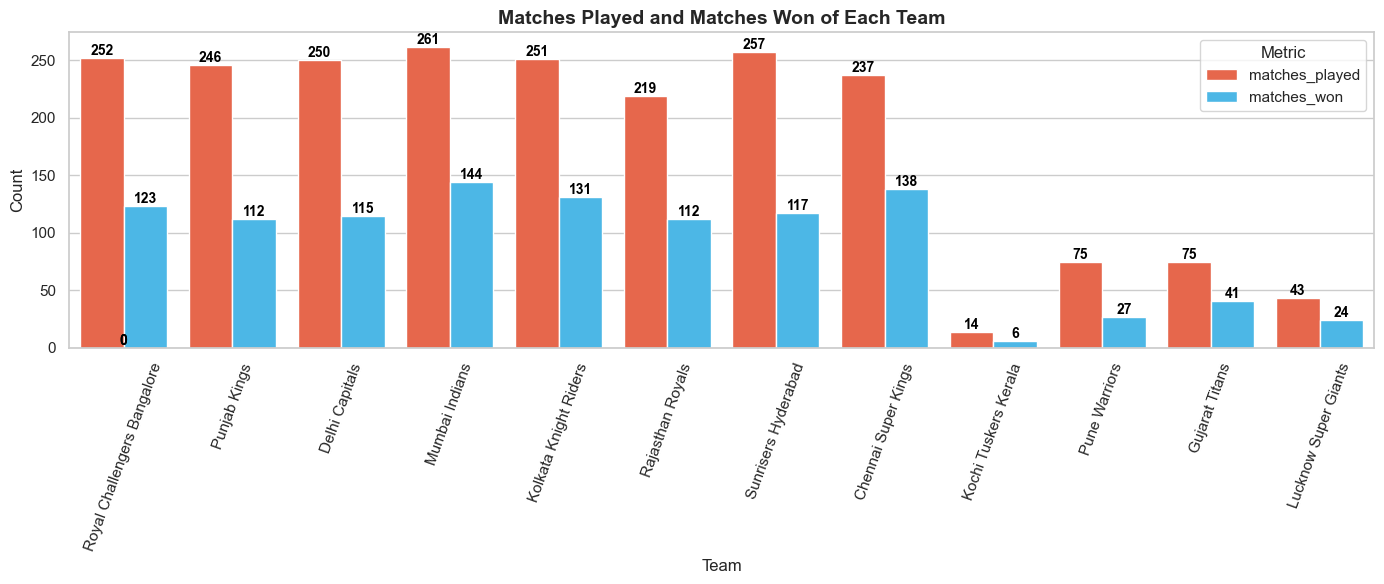

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt data
team_stats_melted = team_stats.melt(
    id_vars=['team_name'], 
    value_vars=['matches_played', 'matches_won'], 
    var_name='Metric', 
    value_name='Value'
)

plt.figure(figsize=(14, 6))

# Use bright color palette
bright_colors = ['#FF5733', '#33C1FF']   # Bright orange & bright blue

ax = sns.barplot(x='team_name', y='Value', hue='Metric', data=team_stats_melted, palette=bright_colors)

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',(p.get_x() + p.get_width() / 2., height),ha='center',va='bottom',fontsize=10,fontweight='bold',color='black')

plt.title('Matches Played and Matches Won of Each Team', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=70)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

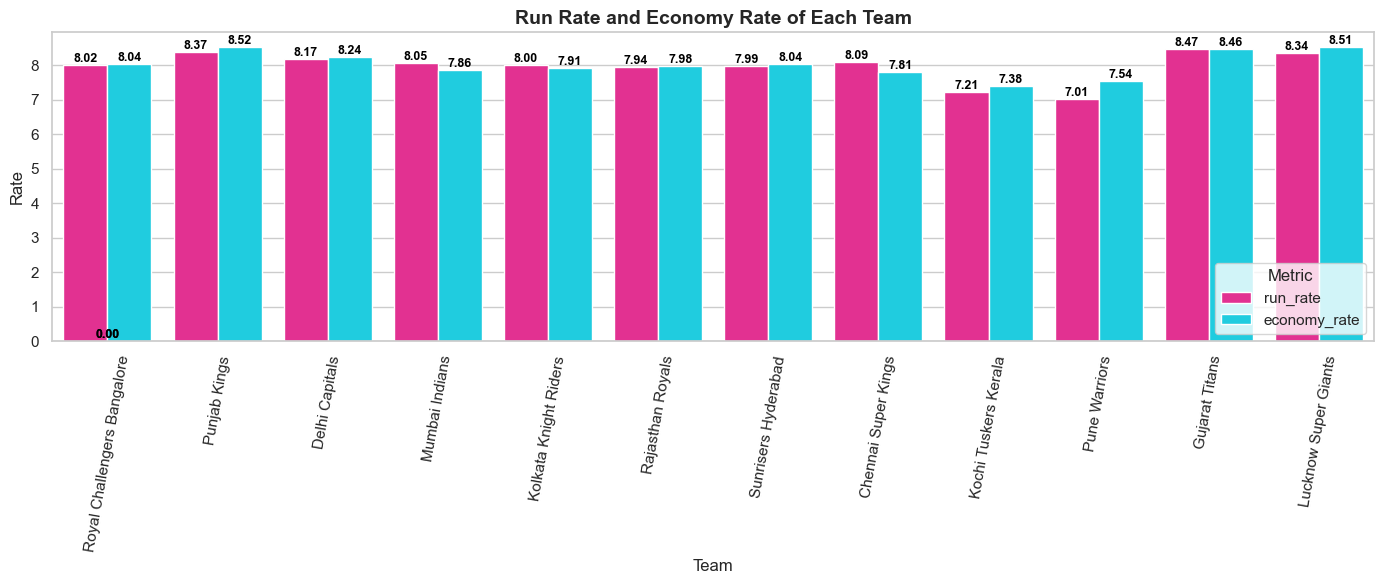

In [47]:


# Melt data
team_stats_melted = team_stats.melt(
    id_vars=['team_name'], 
    value_vars=['run_rate', 'economy_rate'], 
    var_name='Metric', 
    value_name='Value'
)

plt.figure(figsize=(14, 6))

# Bright contrasting colors
bright_colors = ['#FF1493', '#00E5FF']   # Bright pink & neon cyan

ax = sns.barplot(
    x='team_name',
    y='Value',
    hue='Metric',
    data=team_stats_melted,
    palette=bright_colors
)

# Add value labels (2 decimal places)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Run Rate and Economy Rate of Each Team', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.xticks(rotation=80)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

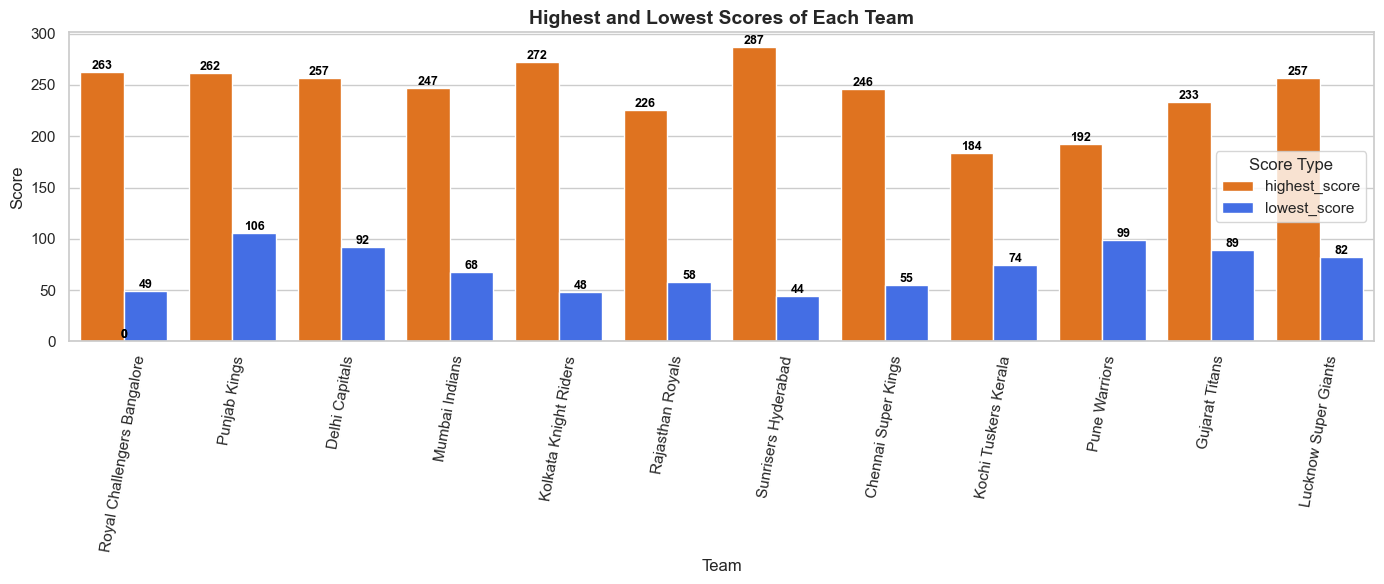

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

team_stats_melted = team_stats.melt(
    id_vars=['team_name'], 
    value_vars=['highest_score', 'lowest_score'], 
    var_name='Score Type', 
    value_name='Score'
)

# Bright contrasting colors
bright_colors = ['#FF6F00', '#2962FF']   # Bright orange & royal blue

ax = sns.barplot(
    x='team_name',
    y='Score',
    hue='Score Type',
    data=team_stats_melted,
    palette=bright_colors
)

# Add score labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Highest and Lowest Scores of Each Team', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=80)
plt.legend(title='Score Type')
plt.tight_layout()
plt.show()

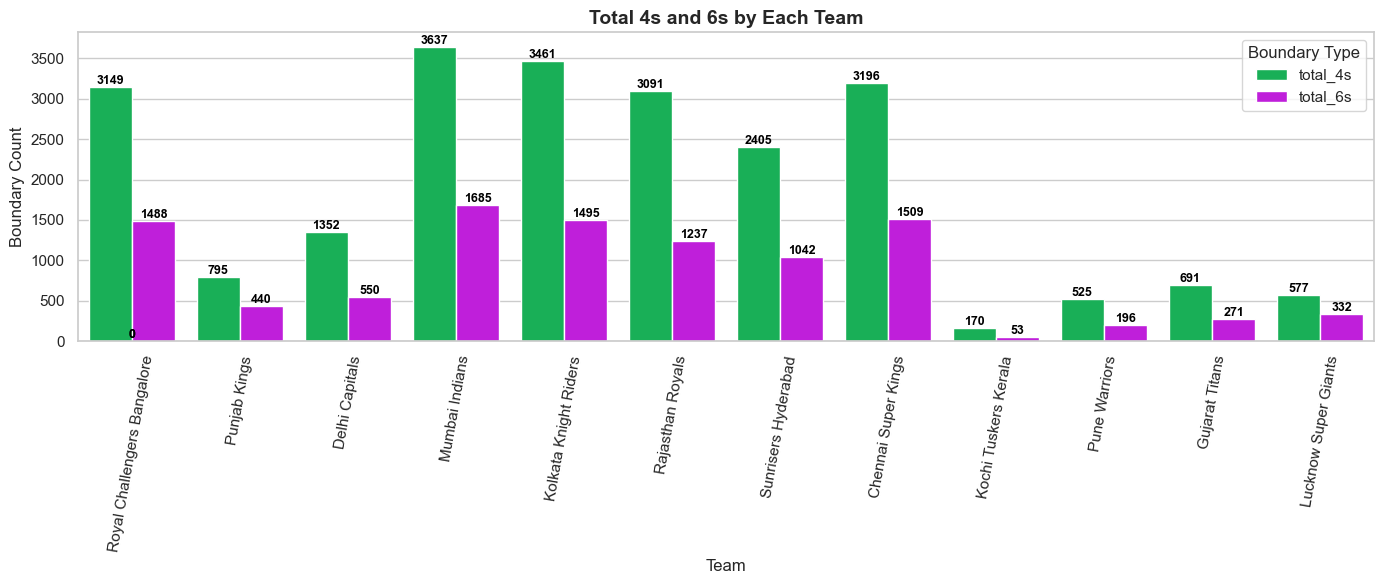

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

team_stats_melted = team_stats.melt(
    id_vars=['team_name'], 
    value_vars=['total_4s', 'total_6s'], 
    var_name='Boundary Type', 
    value_name='Count'
)

# Strong bright IPL-style colors
bright_colors = ['#00C853', '#D500F9']   # Neon green (4s) & bright purple (6s)

ax = sns.barplot(
    x='team_name',
    y='Count',
    hue='Boundary Type',
    data=team_stats_melted,
    palette=bright_colors
)

# Add count labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Total 4s and 6s by Each Team', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Boundary Count', fontsize=12)
plt.xticks(rotation=80)
plt.legend(title='Boundary Type')
plt.tight_layout()
plt.show()

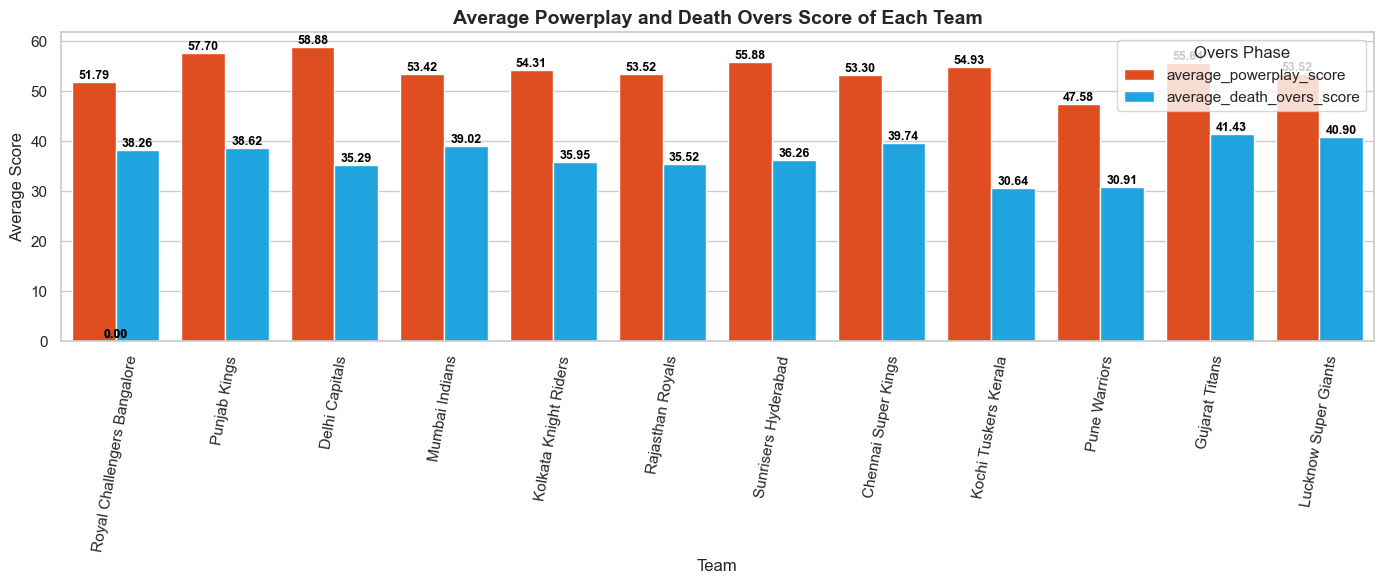

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

team_stats_melted = team_stats.melt(
    id_vars=['team_name'], 
    value_vars=['average_powerplay_score', 'average_death_overs_score'], 
    var_name='Overs Phase', 
    value_name='Average Score'
)

# Bright contrasting colors
bright_colors = ['#FF3D00', '#00B0FF']   # Bright red-orange & electric blue

ax = sns.barplot(
    x='team_name',
    y='Average Score',
    hue='Overs Phase',
    data=team_stats_melted,
    palette=bright_colors
)

# Add value labels (2 decimal places)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Average Powerplay and Death Overs Score of Each Team', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=80)
plt.legend(title='Overs Phase')
plt.tight_layout()
plt.show()

2. Player Performance

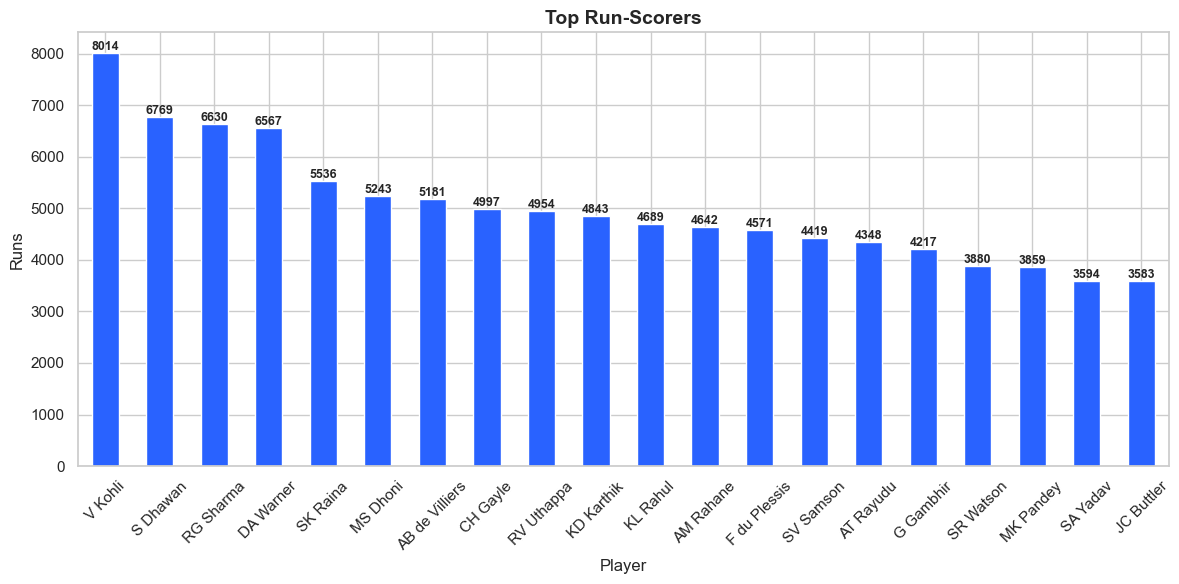

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

top_run_scorers = players['runs'].nlargest(20)

ax = top_run_scorers.plot(
    kind='bar',
    color='#2962FF'   # Bright royal blue
)

# Add total run labels on bars
for i, value in enumerate(top_run_scorers):
    ax.text(
        i, 
        value, 
        str(int(value)), 
        ha='center', 
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel('Player', fontsize=12)
plt.ylabel('Runs', fontsize=12)
plt.title('Top Run-Scorers', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

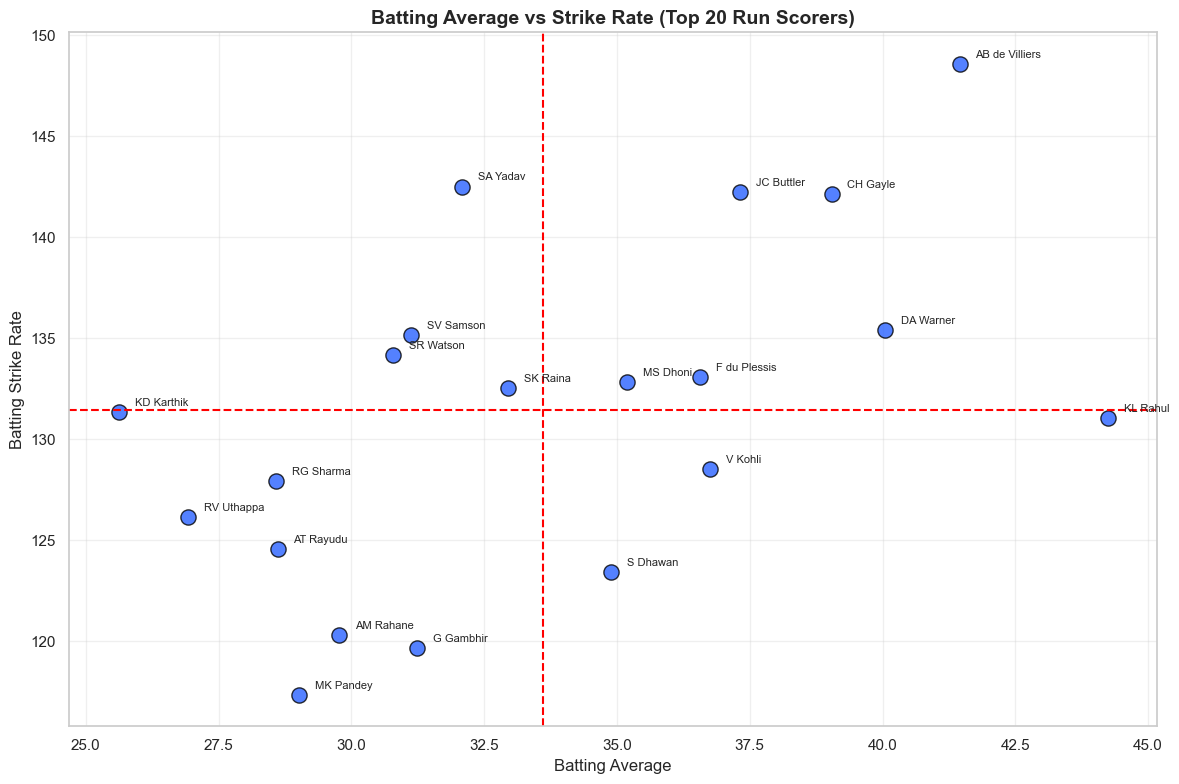

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 20 run scorers
top_run_scorers = players.nlargest(20, 'runs')

plt.figure(figsize=(12, 8))

# Calculate averages for quadrant reference
avg_batting_avg = top_run_scorers['batting_avg'].mean()
avg_strike_rate = top_run_scorers['batting_strike_rate'].mean()

# Scatter plot
plt.scatter(
    top_run_scorers['batting_avg'],
    top_run_scorers['batting_strike_rate'],
    s=120,
    color='#2962FF',
    edgecolor='black',
    alpha=0.8
)

# Add quadrant reference lines
plt.axvline(avg_batting_avg, color='red', linestyle='--', linewidth=1.5)
plt.axhline(avg_strike_rate, color='red', linestyle='--', linewidth=1.5)

# Annotate player names (smaller font for clarity)
for i, player in top_run_scorers.iterrows():
    plt.text(
        player['batting_avg'] + 0.3,
        player['batting_strike_rate'] + 0.3,
        i,
        fontsize=8
    )

plt.xlabel('Batting Average', fontsize=12)
plt.ylabel('Batting Strike Rate', fontsize=12)
plt.title('Batting Average vs Strike Rate (Top 20 Run Scorers)', fontsize=14, fontweight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

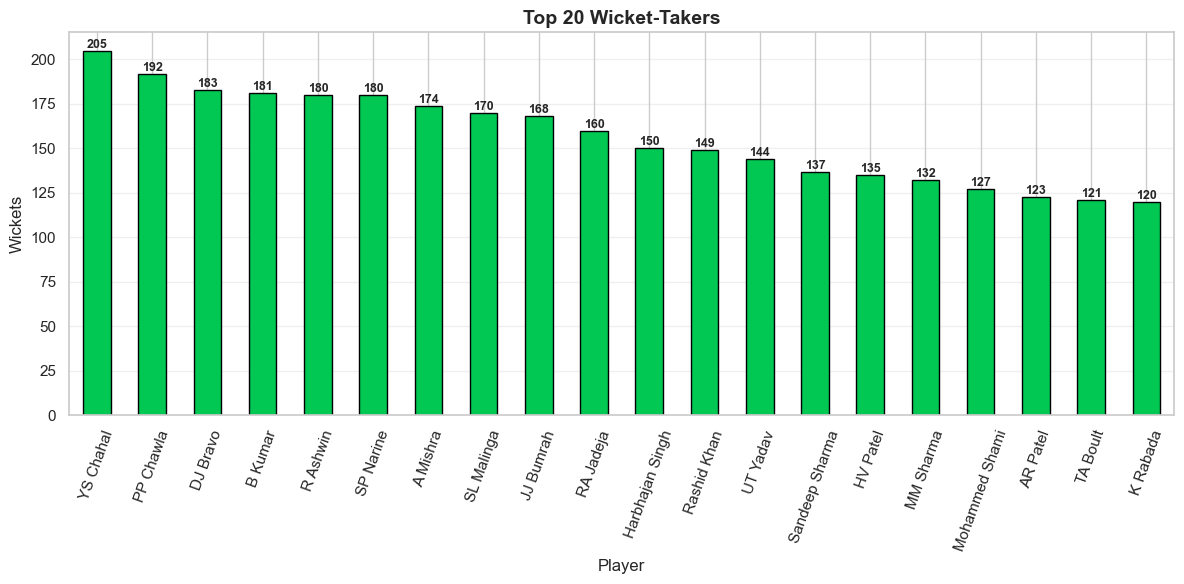

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

top_wicket_takers = players['wickets'].nlargest(20)

ax = top_wicket_takers.plot(
    kind='bar',
    color='#00C853',     # Bright green
    edgecolor='black'
)

# Add wicket count labels on top
for i, value in enumerate(top_wicket_takers):
    ax.text(
        i,
        value,
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel('Player', fontsize=12)
plt.ylabel('Wickets', fontsize=12)
plt.title('Top 20 Wicket-Takers', fontsize=14, fontweight='bold')

plt.xticks(rotation=70)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

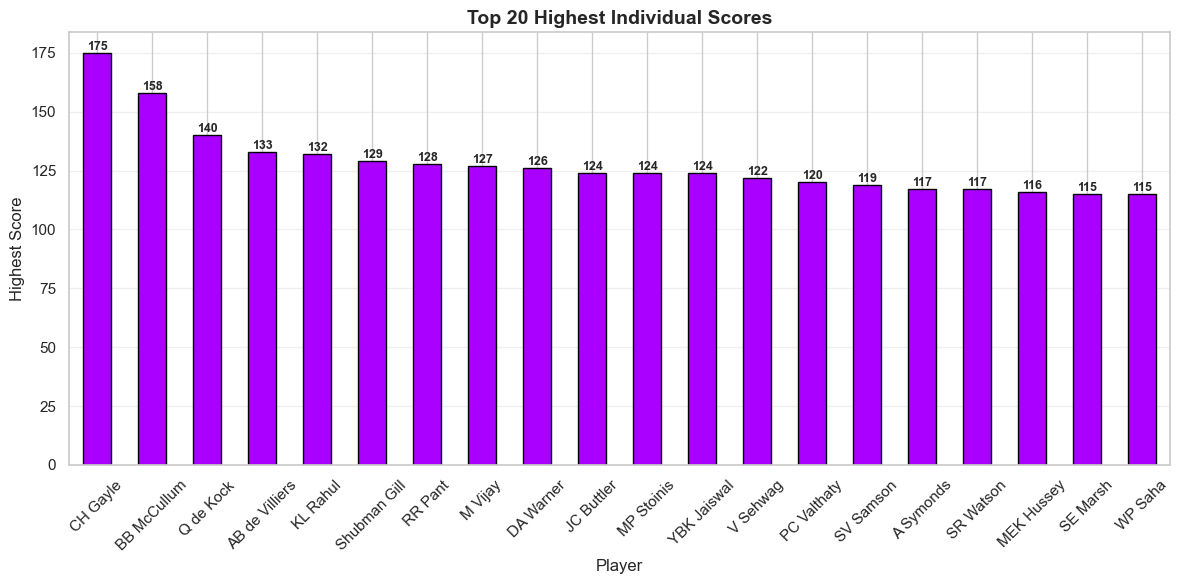

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

highest_scores = players['highest_score'].nlargest(20)

ax = highest_scores.plot(
    kind='bar',
    color='#AA00FF',      # Bright violet
    edgecolor='black'
)

# Add score labels on top
for i, value in enumerate(highest_scores):
    ax.text(
        i,
        value,
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel('Player', fontsize=12)
plt.ylabel('Highest Score', fontsize=12)
plt.title('Top 20 Highest Individual Scores', fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

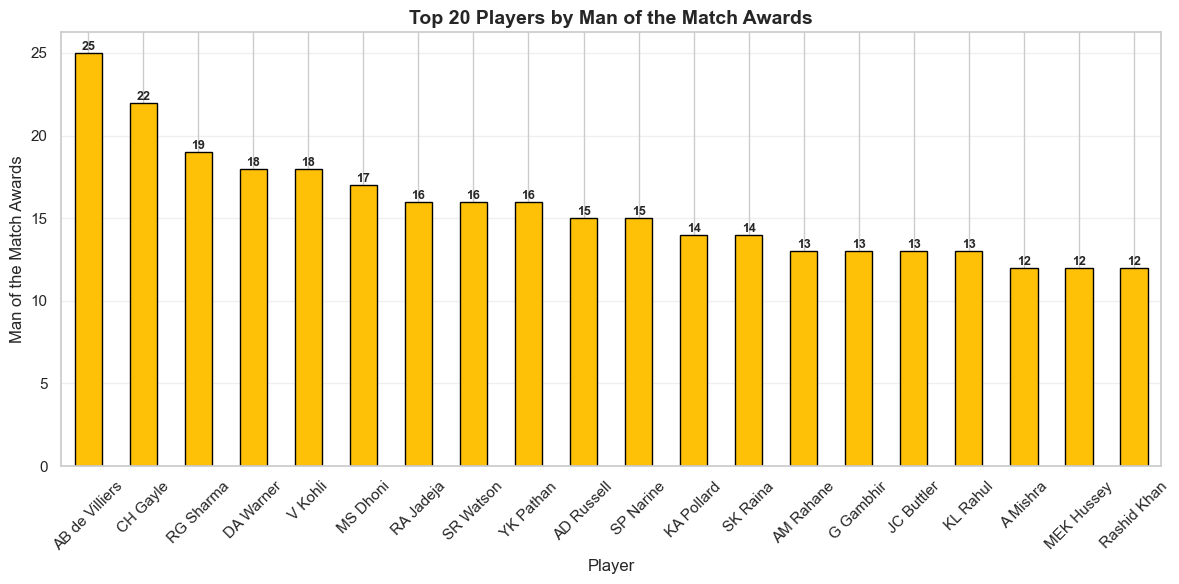

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

top_mom_players = players['man_of_the_match_count'].nlargest(20)

ax = top_mom_players.plot(
    kind='bar',
    color='#FFC107',      # Bright gold
    edgecolor='black'
)

# Add MOM count labels
for i, value in enumerate(top_mom_players):
    ax.text(
        i,
        value,
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel('Player', fontsize=12)
plt.ylabel('Man of the Match Awards', fontsize=12)
plt.title('Top 20 Players by Man of the Match Awards', fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

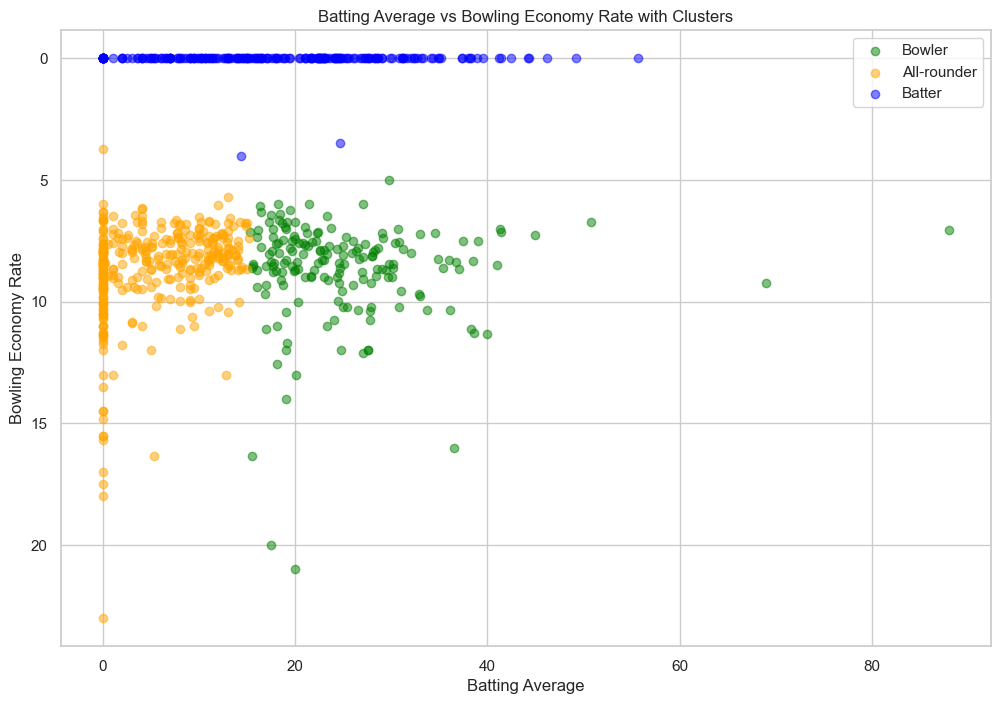

In [56]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Copy the DataFrame
players_copy = players.copy()

players_copy = players_copy[['bowling_econ', 'batting_avg']]

# Check for NaN or infinite values
players_copy = players_copy.replace([float('inf'), -float('inf')], pd.NA)  # Replace inf with NaN
players_copy = players_copy.dropna()  # Drop rows with NaN values

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(players_copy)

# Apply K-Means clustering
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=0)
clusters = kmeans.fit_predict(scaled_features)

# Add the cluster column to the copied DataFrame
players_copy['clusters'] = clusters

players = players.join(players_copy['clusters'], how='left', rsuffix='_cluster')

# Define cluster labels and colors
cluster_labels = {0: 'Batter', 1: 'Bowler', 2: 'All-rounder'}
colors = {'Batter': 'blue', 'Bowler': 'green', 'All-rounder': 'orange'}

# Map cluster labels to the clusters in the DataFrame
players['cluster'] = players['clusters'].map(cluster_labels)

# Check for NaN values in the 'cluster' column
# print(players['cluster'].isna().sum())

# Plotting Batting Average vs Bowling Economy Rate with clusters
plt.figure(figsize=(12, 8))
# Ensure no NaN values in 'cluster' column before plotting
players_no_nan = players.dropna(subset=['cluster'])

for cluster in players_no_nan['cluster'].unique():
    subset = players_no_nan[players_no_nan['cluster'] == cluster]
    plt.scatter(subset['batting_avg'], subset['bowling_econ'], 
                color=colors[cluster], label=cluster, alpha=0.5)

plt.xlabel('Batting Average')
plt.ylabel('Bowling Economy Rate')
plt.title('Batting Average vs Bowling Economy Rate with Clusters')
plt.gca().invert_yaxis()  # Invert y-axis to show better economy rates higher up
plt.legend()
plt.show()

3. Seasonal Analysis

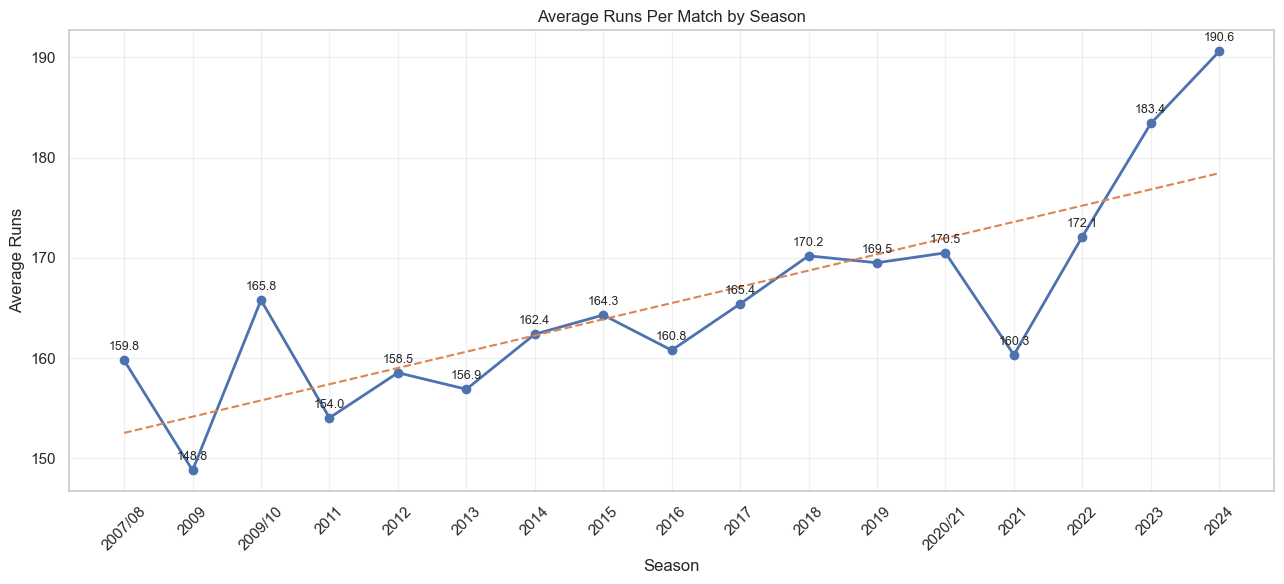

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert season column to string
matches['season'] = matches['season'].astype(str)

# Calculate seasonal average runs
seasonal_runs = matches.groupby('season')['target_runs'].mean().reset_index()
seasonal_runs.columns = ['season', 'average_runs']

# Sort properly by extracting starting year
seasonal_runs['season_sort'] = seasonal_runs['season'].apply(lambda x: int(x.split('/')[0]))
seasonal_runs = seasonal_runs.sort_values('season_sort')

# Plot
plt.figure(figsize=(13, 6))

plt.plot(
    seasonal_runs['season'],
    seasonal_runs['average_runs'],
    marker='o',
    linewidth=2,
)

# Add value labels
for i, value in enumerate(seasonal_runs['average_runs']):
    plt.text(i, value + 1, f'{value:.1f}', ha='center', fontsize=9)

# Add trend line
z = np.polyfit(range(len(seasonal_runs)), seasonal_runs['average_runs'], 1)
p = np.poly1d(z)
plt.plot(seasonal_runs['season'], p(range(len(seasonal_runs))),
         linestyle='--')

plt.title('Average Runs Per Match by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

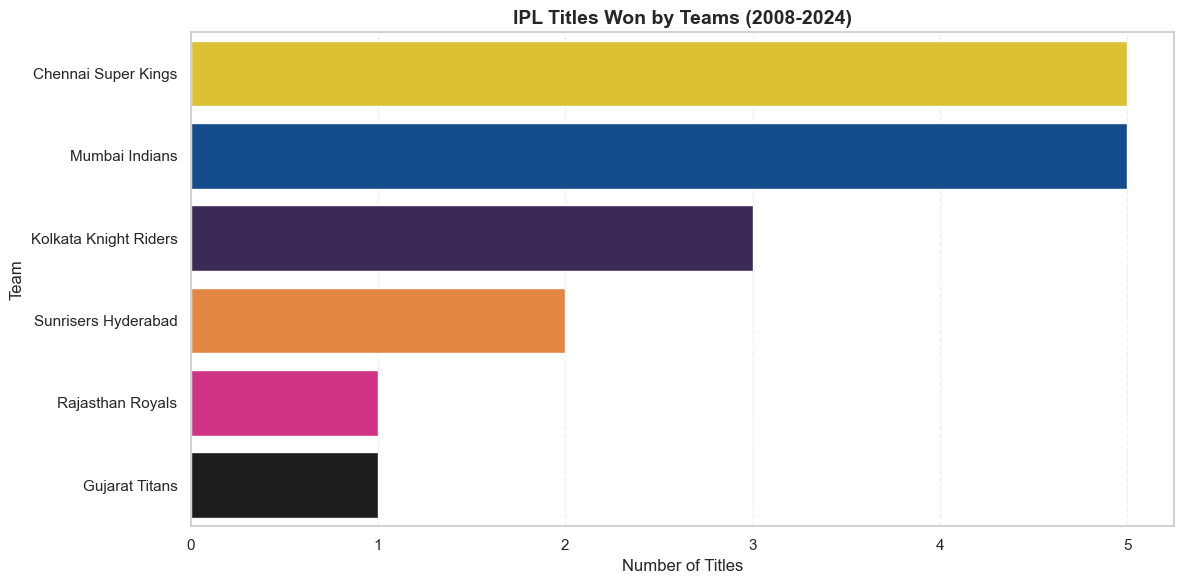

In [58]:
# ================= FINAL MATCHES =================
if 'match_type' in matches.columns:
    final_matches = matches[matches['match_type'] == 'Final']
else:
    # fallback if column not present (older datasets)
    final_matches = matches[matches['date'].notna()].groupby('season_end').tail(1)

# ================= TEAM COLORS =================
team_colors = {
    'Mumbai Indians': '#004BA0',
    'Chennai Super Kings': '#F7D417',
    'Kolkata Knight Riders': '#3A225D',
    'Sunrisers Hyderabad': '#FF822A',
    'Rajasthan Royals': '#EA1A85',
    'Delhi Capitals': '#17449B',
    'Punjab Kings': '#D71920',
    'Royal Challengers Bangalore': '#DA1818',
    'Gujarat Titans': '#1C1C1C',
    'Lucknow Super Giants': '#00AEEF',
    'Deccan Chargers': '#00BFFF'
}

# ================= PLOT =================
plt.figure(figsize=(12,6))

sns.countplot(
    y='winner',
    data=final_matches,
    order=final_matches['winner'].value_counts().index,
    hue='winner',
    palette=team_colors,
    legend=False
)

plt.title('IPL Titles Won by Teams (2008-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Team')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Winner Prediction Model**

In [59]:
deliveries = deliveries_df.copy()
matches = matches_df.copy()

In [60]:
# Calculate 1st innings scores safely
inning_scores = (
    deliveries
    .groupby(['match_id', 'inning'])['total_runs']
    .sum()
    .reset_index()
)

inning_scores = inning_scores[inning_scores['inning'] == 1]
inning_scores.head()

,match_id,inning,total_runs
0,335982,1,222
2,335983,1,240
4,335984,1,129
6,335985,1,165
8,335986,1,110


In [61]:

# Create target
inning_scores['target'] = inning_scores['total_runs'] + 1
inning_scores.head()

,match_id,inning,total_runs,target
0,335982,1,222,223
2,335983,1,240,241
4,335984,1,129,130
6,335985,1,165,166
8,335986,1,110,111


In [62]:
# Rename id column safely
if 'id' in matches.columns:
    matches.rename(columns={'id': 'match_id'}, inplace=True)

matches.head()

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [63]:
# Merge target safely
matches = matches.merge(
    inning_scores[['match_id', 'target']],
    on='match_id',
    how='inner'
)

matches.head()

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,target
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,223
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,241
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,130
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,166
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,111


In [64]:
# View unique teams
matches['team1'].unique()

<StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [65]:

# Mapping dictionary for old names to standardized names
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Pune Warriors',
    'Rising Pune Supergiant': 'Pune Warriors',
    'Gujarat Lions': 'Gujarat Titans',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
}

team_columns = ['winner', 'team1', 'team2', 'toss_winner']

# Replace team names only for existing columns
existing_team_columns = [col for col in team_columns if col in matches.columns]
matches[existing_team_columns] = matches[existing_team_columns].replace(team_name_mapping)

In [66]:
# Teams that will play in 2025 season
teams_2025 = [
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bangalore',
    'Sunrisers Hyderabad',
]

# Filter matches safely
matches = matches[
    matches['team1'].isin(teams_2025) &
    matches['team2'].isin(teams_2025)
]

matches.head()

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,target
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,223
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,241
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,130
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,166
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,111


In [67]:
# View unique cities safely
if 'city' in matches.columns:
    matches['city'].unique()

# Replace city names safely
map_city_names = {'Bengaluru': 'Bangalore'}
if 'city' in matches.columns:
    matches['city'] = matches['city'].replace(map_city_names)

if 'city' in matches.columns:
    matches['city'].unique()

In [68]:
# Check missing values
matches.isnull().sum()

match_id             0
season               0
city                51
date                 0
match_type           0
player_of_match      4
venue                0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               0
result_margin       18
target_runs          2
target_overs         2
super_over           0
method             989
umpire1              0
umpire2              0
target               0
dtype: int64

In [69]:
# Extract only selected columns safely
required_cols = ['match_id', 'season', 'city', 'team1', 'team2', 'winner', 'target']
existing_cols = [col for col in required_cols if col in matches.columns]

matches = matches[existing_cols].dropna()
matches.head()

,match_id,season,city,team1,team2,winner,target
0,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223
1,335983,2007/08,Chandigarh,Punjab Kings,Chennai Super Kings,Chennai Super Kings,241
2,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130
3,335985,2007/08,Mumbai,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,166
4,335986,2007/08,Kolkata,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders,111


In [70]:
matches.isnull().sum()

match_id    0
season      0
city        0
team1       0
team2       0
winner      0
target      0
dtype: int64

In [71]:
# Replace team names in deliveries safely
if 'batting_team' in deliveries.columns:
    deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_mapping)

if 'bowling_team' in deliveries.columns:
    deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_name_mapping)


# Filter deliveries for 2025 teams safely
deliveries = deliveries[
    deliveries['batting_team'].isin(teams_2025) &
    deliveries['bowling_team'].isin(teams_2025)
]

deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [72]:
# Merge matches & deliveries safely
final = matches.merge(deliveries, on='match_id', how='inner')
final.head()


,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,1,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,1,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,1,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,1,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,1,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [73]:
# Get only second inning matches safely
if 'inning' in final.columns:
    final = final[final['inning'] == 2]

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,AB Dinda,W Jaffer,1,0,1,NaN,0,NaN,NaN,NaN
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,AB Dinda,R Dravid,0,1,1,wides,0,NaN,NaN,NaN
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,AB Dinda,R Dravid,0,0,0,NaN,0,NaN,NaN,NaN
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,AB Dinda,R Dravid,1,0,1,NaN,0,NaN,NaN,NaN
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,AB Dinda,W Jaffer,1,0,1,NaN,0,NaN,NaN,NaN


In [74]:
# Add 'current_score'
final.loc[:, 'current_score'] = (
    final.groupby('match_id')['total_runs']
    .cumsum()
)

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,W Jaffer,1,0,1,NaN,0,NaN,NaN,NaN,1
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,R Dravid,0,1,1,wides,0,NaN,NaN,NaN,2
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,R Dravid,0,0,0,NaN,0,NaN,NaN,NaN,2
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,R Dravid,1,0,1,NaN,0,NaN,NaN,NaN,3
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,W Jaffer,1,0,1,NaN,0,NaN,NaN,NaN,4


In [75]:
# Add 'runs_left'
final.loc[:, 'runs_left'] = np.where(
    final['target'] - final['current_score'] >= 0,
    final['target'] - final['current_score'],
    0
)

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,0,1,NaN,0,NaN,NaN,NaN,1,222
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,1,1,wides,0,NaN,NaN,NaN,2,221
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,0,0,NaN,0,NaN,NaN,NaN,2,221
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,0,1,NaN,0,NaN,NaN,NaN,3,220
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,0,1,NaN,0,NaN,NaN,NaN,4,219


In [76]:
# Add 'balls_left'
final.loc[:, 'balls_left'] = np.where(
    120 - (final['over'] * 6 + final['ball']) >= 0,
    120 - (final['over'] * 6 + final['ball']),
    0
)

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,1,NaN,0,NaN,NaN,NaN,1,222,119
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,1,wides,0,NaN,NaN,NaN,2,221,118
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,0,NaN,0,NaN,NaN,NaN,2,221,117
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,1,NaN,0,NaN,NaN,NaN,3,220,116
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,1,NaN,0,NaN,NaN,NaN,4,219,115


In [77]:
# Add 'wickets_left'
final.loc[:, 'wickets_left'] = (
    10 - final.groupby('match_id')['is_wicket'].cumsum()
)

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,NaN,0,NaN,NaN,NaN,1,222,119,10
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,wides,0,NaN,NaN,NaN,2,221,118,10
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,NaN,0,NaN,NaN,NaN,2,221,117,10
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,NaN,0,NaN,NaN,NaN,3,220,116,10
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,1,NaN,0,NaN,NaN,NaN,4,219,115,10


In [78]:

# Calculate 'current_run_rate'
final['current_run_rate'] = np.where(
    120 - final['balls_left'] > 0,
    (final['current_score'] * 6) / (120 - final['balls_left']),
    0
)


# Calculate 'required_run_rate'
final['required_run_rate'] = np.where(
    final['balls_left'] > 0,
    (final['runs_left'] * 6) / final['balls_left'],
    np.where(final['runs_left'] > 0, 1e6, 0)
)

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,NaN,NaN,NaN,1,222,119,10,6.0,11.193277
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,NaN,NaN,NaN,2,221,118,10,6.0,11.237288
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,NaN,NaN,NaN,2,221,117,10,4.0,11.333333
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,NaN,NaN,NaN,3,220,116,10,4.5,11.379310
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,0,NaN,NaN,NaN,4,219,115,10,4.8,11.426087


In [79]:

# Result column safely
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

final['result'] = final.apply(result, axis=1)
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate,result
124,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,NaN,NaN,NaN,1,222,119,10,6.0,11.193277,0
125,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,NaN,NaN,NaN,2,221,118,10,6.0,11.237288,0
126,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,NaN,NaN,NaN,2,221,117,10,4.0,11.333333,0
127,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,NaN,NaN,NaN,3,220,116,10,4.5,11.379310,0
128,335982,2007/08,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223,2,Royal Challengers Bangalore,Kolkata Knight Riders,...,NaN,NaN,NaN,4,219,115,10,4.8,11.426087,0


In [80]:
# Final dataset for prediction
winning_pred = final[
    ['season', 'batting_team', 'bowling_team', 'city',
     'runs_left', 'balls_left', 'wickets_left',
     'current_run_rate', 'required_run_rate', 'target', 'result']
].copy()

winning_pred.head()

,season,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate,target,result
124,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,222,119,10,6.0,11.193277,223,0
125,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,221,118,10,6.0,11.237288,223,0
126,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,221,117,10,4.0,11.333333,223,0
127,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,220,116,10,4.5,11.379310,223,0
128,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,219,115,10,4.8,11.426087,223,0


In [81]:

winning_pred['batting_team'].unique()

<StringArray>
['Royal Challengers Bangalore',                'Punjab Kings',
              'Delhi Capitals',       'Kolkata Knight Riders',
            'Rajasthan Royals',              'Mumbai Indians',
         'Chennai Super Kings',         'Sunrisers Hyderabad',
              'Gujarat Titans',        'Lucknow Super Giants']
Length: 10, dtype: str

In [82]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [83]:
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)


In [84]:
train_data = winning_pred[winning_pred['season'] <= 2021]
test_data  = winning_pred[winning_pred['season'] >= 2024]

X_train = train_data.drop(['result', 'season'], axis=1)
y_train = train_data['result']

X_test = test_data.drop(['result', 'season'], axis=1)
y_test = test_data['result']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (84169, 9)
Test size: (8210, 9)


In [85]:
categorical_features = ['batting_team', 'bowling_team', 'city']

numerical_features = [
    'runs_left',
    'balls_left',
    'wickets_left',
    'current_run_rate',
    'required_run_rate',
    'target'
]


In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)


In [87]:
rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=22,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight={0: 1, 1: 1.25},
    random_state=42,
    n_jobs=-1
)


In [88]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)
])


In [89]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [90]:
y_pred = model.predict(X_test)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Random Forest Accuracy: 81.11 %

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      4290
           1       0.82      0.77      0.80      3920

    accuracy                           0.81      8210
   macro avg       0.81      0.81      0.81      8210
weighted avg       0.81      0.81      0.81      8210


Confusion Matrix:

[[3650  640]
 [ 911 3009]]


In [91]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ================= FEATURE ENGINEERING =================
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)

winning_pred['pressure'] = winning_pred['required_run_rate'] - winning_pred['current_run_rate']
winning_pred['balls_per_wicket'] = winning_pred['balls_left'] / (winning_pred['wickets_left'] + 1)
winning_pred['run_rate_ratio'] = winning_pred['current_run_rate'] / (winning_pred['required_run_rate'] + 0.01)

# ================= DATA =================
X = winning_pred.drop(['result','season'], axis=1)
y = winning_pred['result']

# Encode categorical features
categorical_features = ['batting_team','bowling_team','city']

le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Random split (for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ================= LINEAR REGRESSION =================
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict continuous values
y_prob = lr.predict(X_test)

# Convert to 0/1 using threshold
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)

# ================= EVALUATION =================
accuracy = accuracy_score(y_test, y_pred)

print("\n📉 Linear Regression Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train size: (87754, 12)
Test size: (21939, 12)

📉 Linear Regression Accuracy: 77.93 %

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.74      0.76     10462
           1       0.78      0.81      0.79     11477

    accuracy                           0.78     21939
   macro avg       0.78      0.78      0.78     21939
weighted avg       0.78      0.78      0.78     21939


Confusion Matrix:

[[7769 2693]
 [2150 9327]]


In [92]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ================= FEATURE ENGINEERING =================
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)

winning_pred['pressure'] = winning_pred['required_run_rate'] - winning_pred['current_run_rate']
winning_pred['balls_per_wicket'] = winning_pred['balls_left'] / (winning_pred['wickets_left'] + 1)
winning_pred['run_rate_ratio'] = winning_pred['current_run_rate'] / (winning_pred['required_run_rate'] + 0.01)
winning_pred['overs_left'] = winning_pred['balls_left'] / 6

# ================= DATA =================
X = winning_pred.drop(['result','season'], axis=1)
y = winning_pred['result']

# Encode categorical features
categorical_features = ['batting_team','bowling_team','city']
le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ================= SCALING (Important for Logistic) =================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================= LOGISTIC REGRESSION MODEL =================
log_model = LogisticRegression(
    max_iter=300,
    C=1.0,
    solver='lbfgs'
)

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# ================= EVALUATION =================
accuracy = accuracy_score(y_test, y_pred)

print("\n📊 Logistic Regression Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train size: (87754, 13)
Test size: (21939, 13)

📊 Logistic Regression Accuracy: 78.21 %

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.76      0.77     10462
           1       0.78      0.80      0.79     11477

    accuracy                           0.78     21939
   macro avg       0.78      0.78      0.78     21939
weighted avg       0.78      0.78      0.78     21939


Confusion Matrix:

[[7934 2528]
 [2253 9224]]


In [93]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


In [94]:
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)


In [95]:
train_data = winning_pred[winning_pred['season'] <= 2021]
test_data  = winning_pred[winning_pred['season'] >= 2024]

X_train = train_data.drop(['result', 'season'], axis=1)
y_train = train_data['result']

X_test = test_data.drop(['result', 'season'], axis=1)
y_test = test_data['result']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (84169, 13)
Test size: (8210, 13)


In [96]:
categorical_features = ['batting_team', 'bowling_team', 'city']

numerical_features = [
    'runs_left',
    'balls_left',
    'wickets_left',
    'current_run_rate',
    'required_run_rate',
    'target'
]


In [97]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)


In [98]:
xgb = XGBClassifier(
    n_estimators=1200,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


In [99]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])


In [100]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [101]:
y_pred = model.predict(X_test)

print("\nXGBoost Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



XGBoost Accuracy: 82.38 %

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.88      0.84      4290
           1       0.86      0.76      0.80      3920

    accuracy                           0.82      8210
   macro avg       0.83      0.82      0.82      8210
weighted avg       0.83      0.82      0.82      8210


Confusion Matrix:

[[3786  504]
 [ 943 2977]]


In [102]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================= DATA SPLIT =================
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)

train_data = winning_pred[winning_pred['season'] <= 2021]
test_data  = winning_pred[winning_pred['season'] >= 2024]

X_train = train_data.drop(['result', 'season'], axis=1)
y_train = train_data['result']

X_test = test_data.drop(['result', 'season'], axis=1)
y_test = test_data['result']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ================= FEATURES =================
categorical_features = ['batting_team', 'bowling_team', 'city']

numerical_features = [
    'runs_left',
    'balls_left',
    'wickets_left',
    'current_run_rate',
    'required_run_rate',
    'target'
]

# ================= CATBOOST MODEL =================
cat_model = CatBoostClassifier(
    iterations=1500,
    depth=8,
    learning_rate=0.02,
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_strength=1,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)
# ================= TRAIN =================
cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# ================= PREDICT =================
y_pred = cat_model.predict(X_test)

print("\nCatBoost Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train size: (84169, 13)
Test size: (8210, 13)
0:	test: 0.8677931	best: 0.8677931 (0)	total: 448ms	remaining: 11m 11s
100:	test: 0.8399062	best: 0.8923991 (11)	total: 28.9s	remaining: 6m 40s
200:	test: 0.8331840	best: 0.8923991 (11)	total: 57.5s	remaining: 6m 11s
300:	test: 0.8235302	best: 0.8923991 (11)	total: 1m 26s	remaining: 5m 42s
400:	test: 0.8171741	best: 0.8923991 (11)	total: 1m 54s	remaining: 5m 13s
500:	test: 0.8164232	best: 0.8923991 (11)	total: 2m 22s	remaining: 4m 43s
600:	test: 0.8196349	best: 0.8923991 (11)	total: 2m 49s	remaining: 4m 13s
700:	test: 0.8201270	best: 0.8923991 (11)	total: 3m 16s	remaining: 3m 44s
800:	test: 0.8216686	best: 0.8923991 (11)	total: 3m 43s	remaining: 3m 15s
900:	test: 0.8211261	best: 0.8923991 (11)	total: 4m 10s	remaining: 2m 46s
1000:	test: 0.8207543	best: 0.8923991 (11)	total: 4m 37s	remaining: 2m 18s
1100:	test: 0.8213972	best: 0.8923991 (11)	total: 5m 2s	remaining: 1m 49s
1200:	test: 0.8209334	best: 0.8923991 (11)	total: 5m 27s	remaining: 1m

In [103]:
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================= DATA SPLIT =================
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)

train_data = winning_pred[winning_pred['season'] <= 2021]
test_data  = winning_pred[winning_pred['season'] >= 2024]

X_train = train_data.drop(['result', 'season'], axis=1)
y_train = train_data['result']

X_test = test_data.drop(['result', 'season'], axis=1)
y_test = test_data['result']

# ================= FEATURES =================
categorical_features = ['batting_team', 'bowling_team', 'city']

numerical_features = [
    'runs_left',
    'balls_left',
    'wickets_left',
    'current_run_rate',
    'required_run_rate',
    'target'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# ================= STRONG LGBM MODEL =================
lgb = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    force_col_wise=True,   # add this
    random_state=42
)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb)
])

# ================= TRAIN =================
model.fit(X_train, y_train)

# ================= PREDICT =================
y_pred = model.predict(X_test)

print("\nLightGBM Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

[LightGBM] [Info] Number of positive: 45536, number of negative: 38633
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 84169, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.541007 -> initscore=0.164396
[LightGBM] [Info] Start training from score 0.164396


f:\ML_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Accuracy: 81.63 %

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.89      0.84      4290
           1       0.86      0.74      0.79      3920

    accuracy                           0.82      8210
   macro avg       0.82      0.81      0.81      8210
weighted avg       0.82      0.82      0.81      8210


Confusion Matrix:

[[3820  470]
 [1038 2882]]


In [104]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ================= FEATURE ENGINEERING =================
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)

winning_pred['pressure'] = winning_pred['required_run_rate'] - winning_pred['current_run_rate']
winning_pred['balls_per_wicket'] = winning_pred['balls_left'] / (winning_pred['wickets_left'] + 1)
winning_pred['run_rate_ratio'] = winning_pred['current_run_rate'] / (winning_pred['required_run_rate'] + 0.01)
winning_pred['overs_left'] = winning_pred['balls_left'] / 6

# ================= DATA =================
X = winning_pred.drop(['result','season'], axis=1)
y = winning_pred['result']

# Encode categorical features
categorical_features = ['batting_team','bowling_team','city']
le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# 🔥 Random split (higher accuracy than season split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ================= DECISION TREE MODEL =================
dt = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

# ================= TRAIN =================
dt.fit(X_train, y_train)

# ================= PREDICT =================
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n🌳 Decision Tree Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train size: (87754, 13)
Test size: (21939, 13)

🌳 Decision Tree Accuracy: 87.58 %

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.87     10462
           1       0.87      0.90      0.88     11477

    accuracy                           0.88     21939
   macro avg       0.88      0.87      0.88     21939
weighted avg       0.88      0.88      0.88     21939


Confusion Matrix:

[[ 8921  1541]
 [ 1184 10293]]


In [105]:
import pandas as pd
import numpy as np

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ================= FEATURE ENGINEERING =================
winning_pred['season'] = winning_pred['season'].astype(str).str[:4].astype(int)

winning_pred['pressure'] = winning_pred['required_run_rate'] - winning_pred['current_run_rate']
winning_pred['balls_per_wicket'] = winning_pred['balls_left'] / (winning_pred['wickets_left'] + 1)
winning_pred['run_rate_ratio'] = winning_pred['current_run_rate'] / (winning_pred['required_run_rate'] + 0.01)

# ================= DATA SPLIT (RANDOM) =================
X = winning_pred.drop(['result','season'], axis=1)
y = winning_pred['result']

# Encode categorical features
categorical_features = ['batting_team','bowling_team','city']
le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ================= EXTRA TREES MODEL =================
et = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=18,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# ================= TRAIN =================
et.fit(X_train, y_train)

# ================= PREDICT =================
y_pred = et.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n🔥 ExtraTrees Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train size: (87754, 13)
Test size: (21939, 13)

🔥 ExtraTrees Accuracy: 93.42 %

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.91      0.93     10462
           1       0.92      0.95      0.94     11477

    accuracy                           0.93     21939
   macro avg       0.94      0.93      0.93     21939
weighted avg       0.93      0.93      0.93     21939


Confusion Matrix:

[[ 9562   900]
 [  544 10933]]


In [106]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# ================== LOAD DATA ==================
file_path = "../data/guru.xlsx"   # Make sure file exists
sheets = pd.read_excel(file_path, sheet_name=None)

matches = sheets['ipl_matches_data'].copy()

# ================== FIX TEAM NAMES ==================
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Gujarat Lions': 'Gujarat Titans'
}

team_cols = ['team1','team2','winner','toss_winner']
matches[team_cols] = matches[team_cols].replace(team_name_mapping)

# ================== VALID TEAMS ==================
teams = [
    "Chennai Super Kings","Delhi Capitals","Gujarat Titans",
    "Kolkata Knight Riders","Lucknow Super Giants",
    "Mumbai Indians","Punjab Kings","Rajasthan Royals",
    "Royal Challengers Bangalore","Sunrisers Hyderabad"
]

matches = matches[
    matches['team1'].isin(teams) &
    matches['team2'].isin(teams)
]

# ================== FEATURE ENGINEERING ==================
matches['city'] = matches['city'].replace({'Bengaluru': 'Bangalore'})

matches['result'] = (matches['winner'] == matches['team1']).astype(int)

data = matches[
    ['season','team1','team2','city','toss_winner','toss_decision','result']
].dropna()

data['season'] = data['season'].astype(str).str[:4].astype(int)

# ================== TRAIN TEST SPLIT ==================
train = data[data['season'] <= 2023]
test  = data[data['season'] >= 2024]

X_train = train.drop(['result','season'], axis=1)
y_train = train['result']

X_test = test.drop(['result','season'], axis=1)
y_test = test['result']

# ================== MODEL PIPELINE ==================
categorical_features = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

et = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=18,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ('prep', preprocessor),
    ('rf', et)
])

# ================== TRAIN MODEL ==================
model.fit(X_train, y_train)



# ================== SAVE MODEL ==================
joblib.dump(model, "../ipl_hf_deploy/ipl_prematch_rf.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
